# Laboratorio 1 — Series de Tiempo · Notebook 2 de 2
### Series por País de residencia — Ingreso de viajeros internacionales a Guatemala


> **Prerrequisito:** revisar primero el **Notebook 1** (`Lab1_Series_Tiempo.ipynb`), que contiene el
> **análisis exploratorio general** (calidad de datos, pandemia, quiebres metodológicos, etc.). Este
> Notebook 2 reutiliza esa misma metodología aplicada a los **tres países de residencia** con mayor
> número acumulado de viajeros.

**Series de este notebook** (criterio: total acumulado de `Turista + Excursionista` en todo el período):
1. **El Salvador**
2. **Estados Unidos de América**
3. **Honduras**

> *Nota:* el top-3 literal incluía "Guatemala", pero corresponde a **residentes nacionales
> retornando** (no es un mercado extranjero) y su serie se corta en 2022 por el cambio de
> granularidad; por eso se excluye y se toma el siguiente país (Honduras). Justificación en el
> `README.md` y en el EDA del Notebook 1.

## 0. Configuración y funciones de análisis

Este notebook es **autocontenido**: define las mismas funciones auxiliares del Notebook 1
(`resumen_serie`, `comparar_descomposicion`, `media_std_movil`, `prueba_adf`, `prueba_kpss`,
`acf_pacf`) para que puedas aplicarlas directamente a las series de países.

In [1]:
# !pip install numpy pandas matplotlib seaborn statsmodels scikit-learn openpyxl

# !pip install pmdarima prophet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Entorno listo.")

Entorno listo.


In [3]:
# ---- Funciones auxiliares (idénticas a las del Notebook 1) ----
def resumen_serie(s):
    return pd.Series({
        "Inicio": s.index.min().strftime("%Y-%m"),
        "Fin": s.index.max().strftime("%Y-%m"),
        "Frecuencia": s.index.freqstr,
        "N observaciones": len(s),
        "Media": s.mean(), "Mínimo": s.min(), "Máximo": s.max(),
    })

def comparar_descomposicion(s, titulo):
    desc_add = seasonal_decompose(s, model="additive", period=12)
    desc_mul = seasonal_decompose(s, model="multiplicative", period=12)
    fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
    for j, (desc, nombre) in enumerate([(desc_add, "Aditiva"), (desc_mul, "Multiplicativa")]):
        axes[0, j].plot(s, color="#333"); axes[0, j].set_title(f"{titulo} — {nombre}")
        axes[1, j].plot(desc.trend, color="#1f77b4"); axes[1, j].set_ylabel("tendencia")
        axes[2, j].plot(desc.seasonal, color="#2ca02c"); axes[2, j].set_ylabel("estacional")
        axes[3, j].plot(desc.resid, color="#d62728", marker=".", ls="none", ms=3)
        axes[3, j].set_ylabel("residuo")
    plt.tight_layout(); plt.show()
    return desc_add, desc_mul

def media_std_movil(s, titulo, ventana=12):
    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(s, color="#bbb", label="serie")
    ax[0].plot(s.rolling(ventana).mean(), color="#1f77b4", label=f"media móvil ({ventana}m)")
    ax[0].set_title(f"{titulo} — media móvil"); ax[0].legend()
    ax[1].plot(s.rolling(ventana).std(), color="#d62728", label=f"std móvil ({ventana}m)")
    ax[1].set_title("Desviación estándar móvil"); ax[1].legend()
    plt.tight_layout(); plt.show()

def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "ESTACIONARIA" if r[1] < 0.05 else "NO estacionaria"
    print(f"ADF  {nombre:32s} estad={r[0]:7.3f}  p-valor={r[1]:.4f}  -> {veredicto}")
    return r[1]

def prueba_kpss(x, nombre=""):
    stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
    veredicto = "NO estacionaria" if p < 0.05 else "ESTACIONARIA"
    print(f"KPSS {nombre:32s} estad={stat:7.3f}  p-valor={p:.4f}  -> {veredicto}")
    return p

def acf_pacf(s, titulo, lags=36):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s.dropna(), lags=lags, ax=ax[0]); ax[0].set_title(f"ACF — {titulo}")
    plot_pacf(s.dropna(), lags=lags, ax=ax[1], method="ywm"); ax[1].set_title(f"PACF — {titulo}")
    plt.tight_layout(); plt.show()

print("Funciones auxiliares cargadas.")

Funciones auxiliares cargadas.


## 1. Carga de datos y construcción de las tres series

Mismo filtro consistente que en el Notebook 1: `Turista + Excursionista`, agregación mensual (`MS`).

In [4]:
ARCHIVO = "Base_Migracion_2009-2026jun.xlsx"
df = pd.read_excel(ARCHIVO, sheet_name="Datos")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))
base = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]

PAISES = ["El Salvador", "Estados Unidos de América", "Honduras"]
rango = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="MS")

series_pais = {}
for p in PAISES:
    s = base[base["País"] == p].groupby("Fecha")["Viajero"].sum().reindex(rango)
    series_pais[p] = s

# Diagnóstico de meses faltantes (deben ser abr-ago 2020: cierre por pandemia)
for p, s in series_pais.items():
    faltan = [d.strftime("%Y-%m") for d in s[s.isna()].index]
    print(f"{p:28s} -> meses sin registro: {faltan}")

El Salvador                  -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']
Estados Unidos de América    -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']
Honduras                     -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']


### 1.1 Tratamiento de los meses del cierre pandémico (abr–ago 2020)

Los únicos meses faltantes son **abril a agosto de 2020**, cuando las fronteras y el aeropuerto
estuvieron cerrados: no hubo arribos registrados. Los rellenamos con **0** (refleja el cierre real).

> ⚠️ **Para el modelado con `log`:** `log(0)` no existe. Cuando transformes la varianza, usa
> `np.log1p` (equivale a `log(1+x)`) o suma una constante pequeña. Estos 5 ceros son el mismo
> **quiebre estructural de la pandemia** discutido en el Notebook 1: tenlo presente al descomponer y
> modelar (considera tratarlos como valores atípicos/intervención si el modelo lo requiere).

In [5]:
for p in PAISES:
    series_pais[p] = series_pais[p].fillna(0.0).asfreq("MS")
    series_pais[p].name = p

serie_sv  = series_pais["El Salvador"]
serie_usa = series_pais["Estados Unidos de América"]
serie_hn  = series_pais["Honduras"]

print("Longitudes (deben ser 210, sin NaN):")
for p, s in series_pais.items():
    print(f"  {p:28s} n={len(s)}  NaN={s.isna().sum()}")

Longitudes (deben ser 210, sin NaN):
  El Salvador                  n=210  NaN=0
  Estados Unidos de América    n=210  NaN=0
  Honduras                     n=210  NaN=0


## 2. Inicio, fin y frecuencia *(Requisito 4a)*

In [6]:
pd.DataFrame({p: resumen_serie(s) for p, s in series_pais.items()})

,El Salvador,Estados Unidos de América,Honduras
Inicio,2009-01,2009-01,2009-01
Fin,2026-06,2026-06,2026-06
Frecuencia,MS,MS,MS
N observaciones,210,210,210
Media,"67,043.50","33,169.90","12,004.64"
Mínimo,0.00,0.00,0.00
Máximo,"190,578.96","78,927.16","35,252.51"


## 3. Gráfico de las series *(Requisito 4b)*

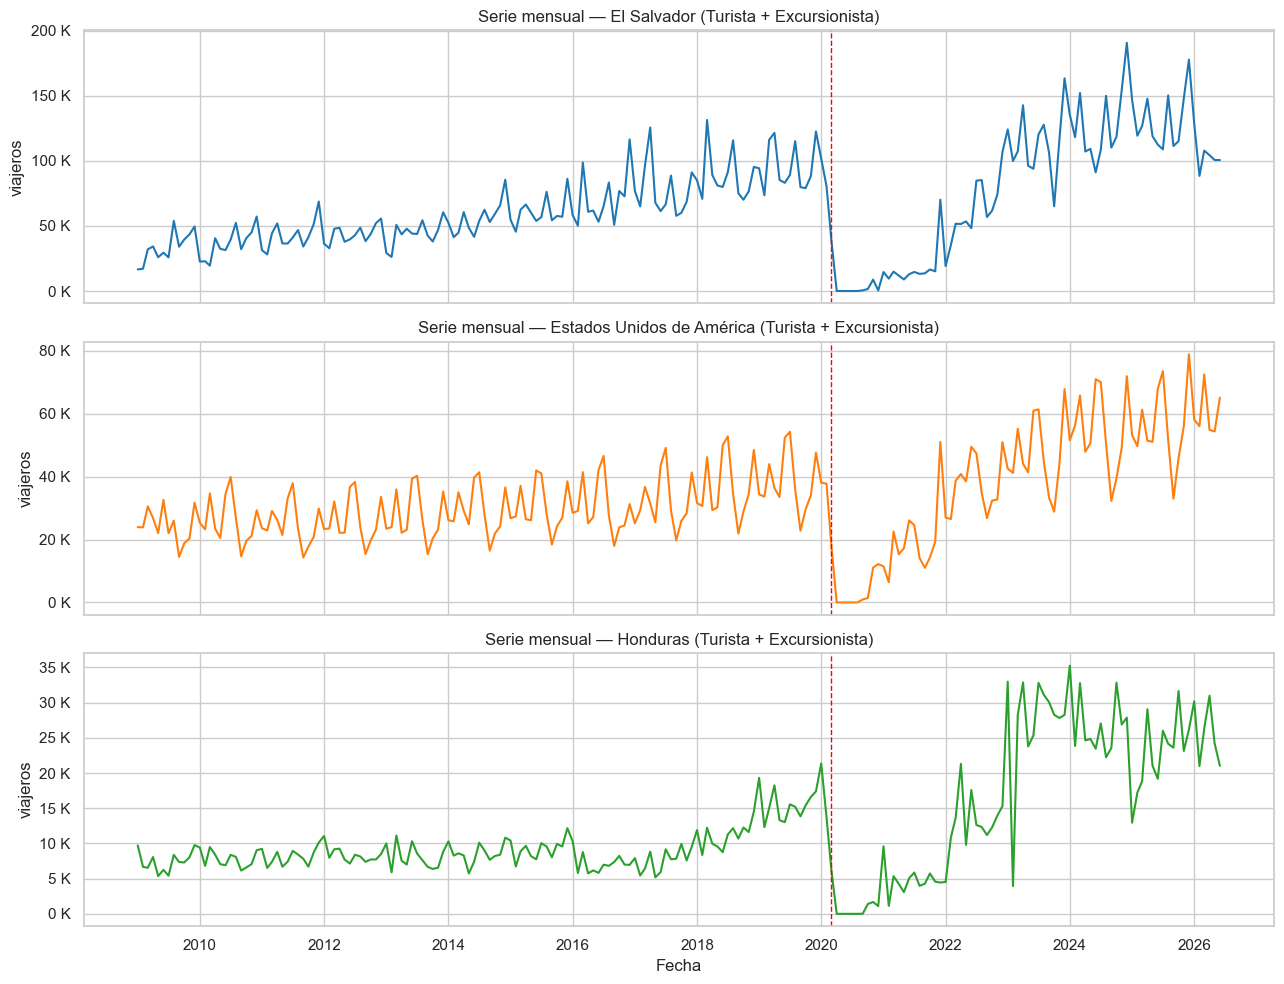

In [7]:
colores = {"El Salvador": "#1f77b4", "Estados Unidos de América": "#ff7f0e", "Honduras": "#2ca02c"}
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, (p, s) in zip(axes, series_pais.items()):
    ax.plot(s.index, s.values, color=colores[p])
    ax.axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1)
    ax.set_title(f"Serie mensual — {p} (Turista + Excursionista)")
    ax.set_ylabel("viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
axes[-1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

**Interpretación a primera vista.**

- **El Salvador** tiene el mayor volumen y una estacionalidad anual marcada. Antes de 2020 crece; entre abril y agosto de 2020 cae a cero por el cierre de fronteras y luego se recupera.
- **Estados Unidos** también crece antes de la pandemia, con un patrón estacional más suave. Desde 2021 muestra una recuperación sostenida.
- **Honduras** tiene el menor nivel y cambios relativos más bruscos. Se observan picos estacionales, el corte de 2020 y una recuperación con mayor variabilidad.

Ninguna serie parece tener media constante. Además, la amplitud de sus cambios aumenta con el nivel, señal de varianza no constante.

## 4. Descomposición, media y varianza *(Requisitos 4c y 4d)*

Como existen ceros reales durante el cierre de 2020, no se puede usar directamente una descomposición multiplicativa ni el logaritmo usual. Aplicamos `log1p(x)`, que acepta ceros y comprime los cambios grandes. Luego usamos descomposición aditiva en la escala transformada.

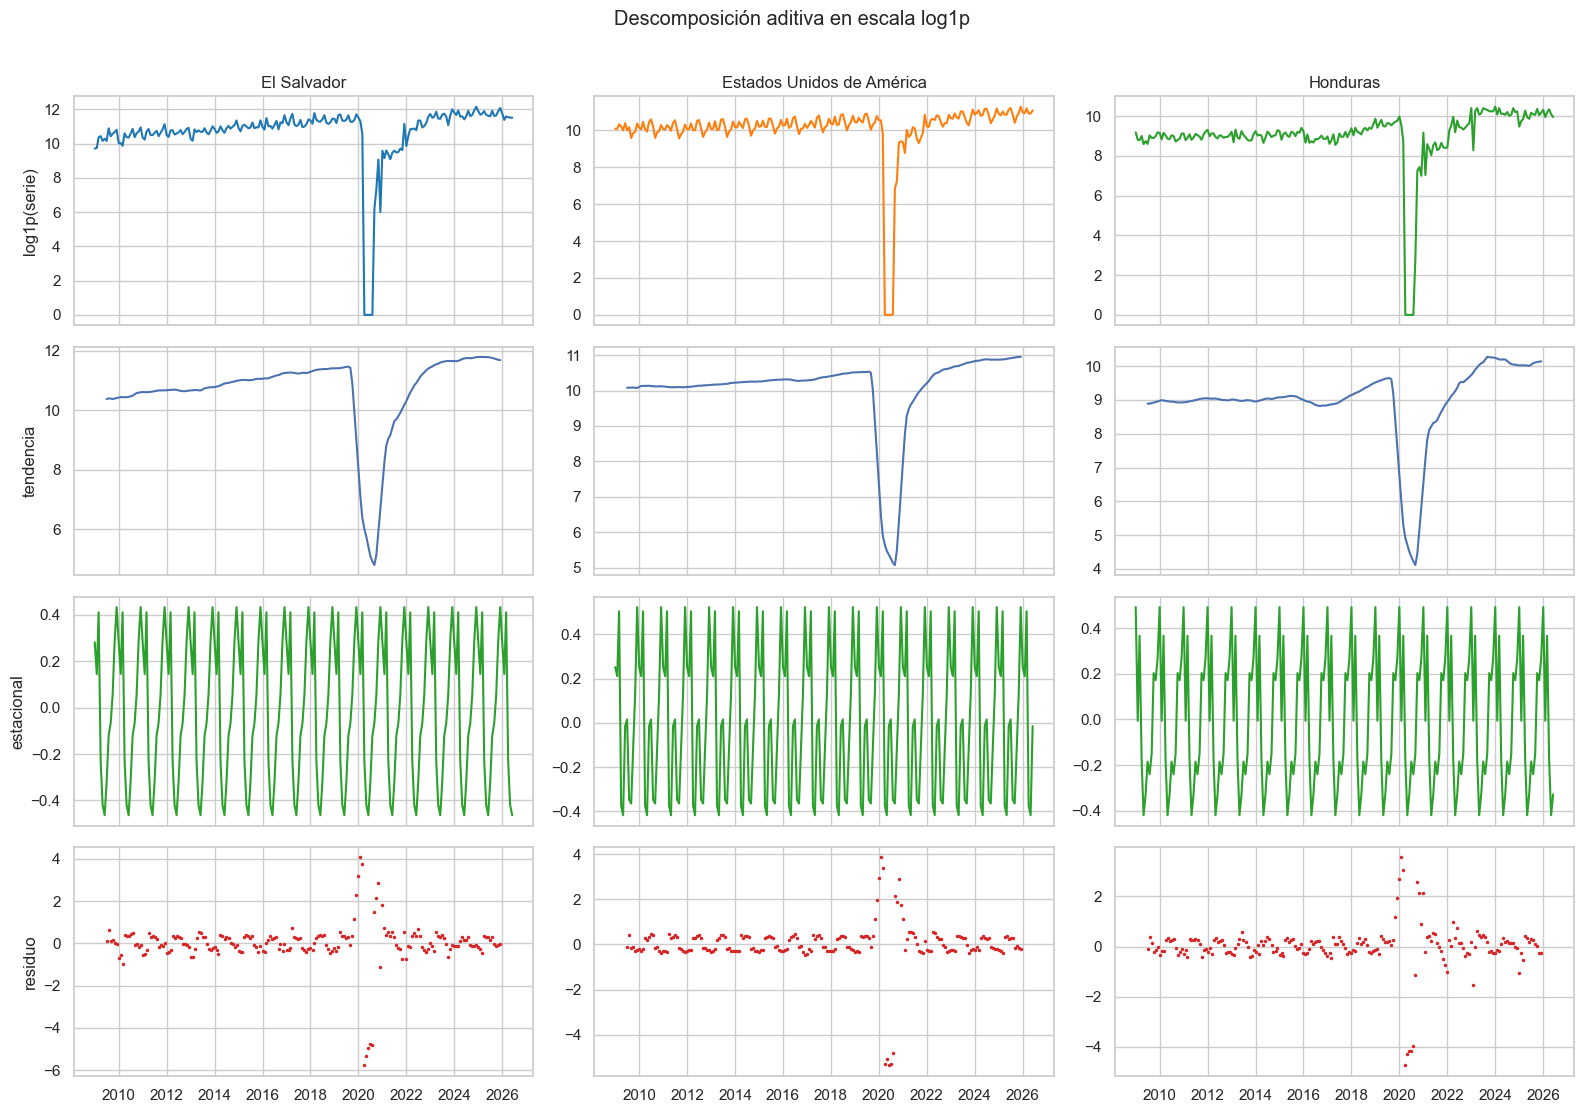

El Salvador                  corr. nivel-dispersión: original=+0.84 | log1p=-0.40
Estados Unidos de América    corr. nivel-dispersión: original=+0.90 | log1p=-0.26
Honduras                     corr. nivel-dispersión: original=+0.72 | log1p=-0.01


In [8]:
series_pais_log = {p: np.log1p(s) for p, s in series_pais.items()}
descomposiciones_pais = {}
fig, axes = plt.subplots(4, 3, figsize=(16, 11), sharex=True)
for j, (p, s_log) in enumerate(series_pais_log.items()):
    desc = seasonal_decompose(s_log, model="additive", period=12)
    descomposiciones_pais[p] = desc
    axes[0,j].plot(s_log,color=colores[p]); axes[0,j].set_title(p)
    axes[1,j].plot(desc.trend); axes[2,j].plot(desc.seasonal,color="#2ca02c")
    axes[3,j].plot(desc.resid,color="#d62728",marker=".",ls="none",ms=3)
for i,e in enumerate(["log1p(serie)","tendencia","estacional","residuo"]): axes[i,0].set_ylabel(e)
plt.suptitle("Descomposición aditiva en escala log1p",y=1.01); plt.tight_layout(); plt.show()
for p,s in series_pais.items():
    pre=s[s.index<"2020-01-01"]; sl=np.log1p(pre)
    co=pre.rolling(12).mean().corr(pre.rolling(12).std())
    cl=sl.rolling(12).mean().corr(sl.rolling(12).std())
    print(f"{p:28s} corr. nivel-dispersión: original={co:+.2f} | log1p={cl:+.2f}")

**Discusión.** Las tendencias aumentan antes de 2020, se hunden durante el cierre y se recuperan después: no hay **estacionariedad en media**. Las componentes estacionales confirman un ciclo de 12 meses. La relación nivel-dispersión en la escala original muestra varianza no constante; `log1p` reduce esa dependencia y conserva los meses con cero. Por ello **sí es necesario transformar** las tres series. El choque pandémico permanece porque es un quiebre real, no un problema de escala.

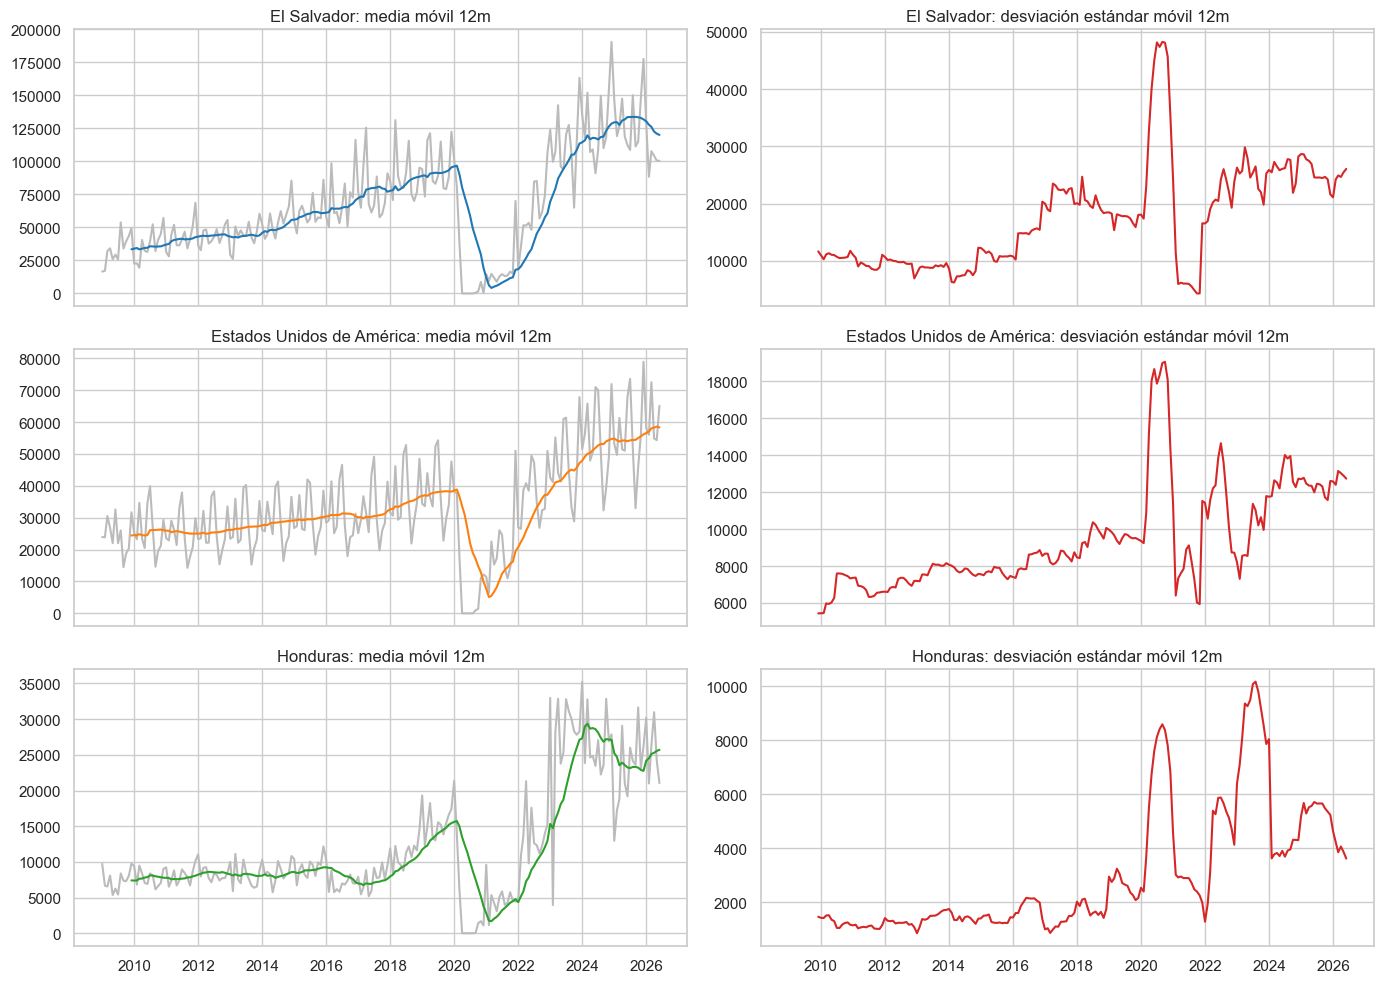

In [9]:
fig,axes=plt.subplots(3,2,figsize=(14,10),sharex=True)
for i,(p,s) in enumerate(series_pais.items()):
    axes[i,0].plot(s,color="#bbb"); axes[i,0].plot(s.rolling(12).mean(),color=colores[p]); axes[i,0].set_title(f"{p}: media móvil 12m")
    axes[i,1].plot(s.rolling(12).std(),color="#d62728"); axes[i,1].set_title(f"{p}: desviación estándar móvil 12m")
plt.tight_layout(); plt.show()

## 5. Estacionariedad en media: ACF y pruebas *(Requisito 4e)*

Una ACF que conserva correlaciones significativas durante muchos rezagos y vuelve a mostrar picos en 12, 24 y 36 meses evidencia persistencia y estacionalidad, incompatibles con media constante.

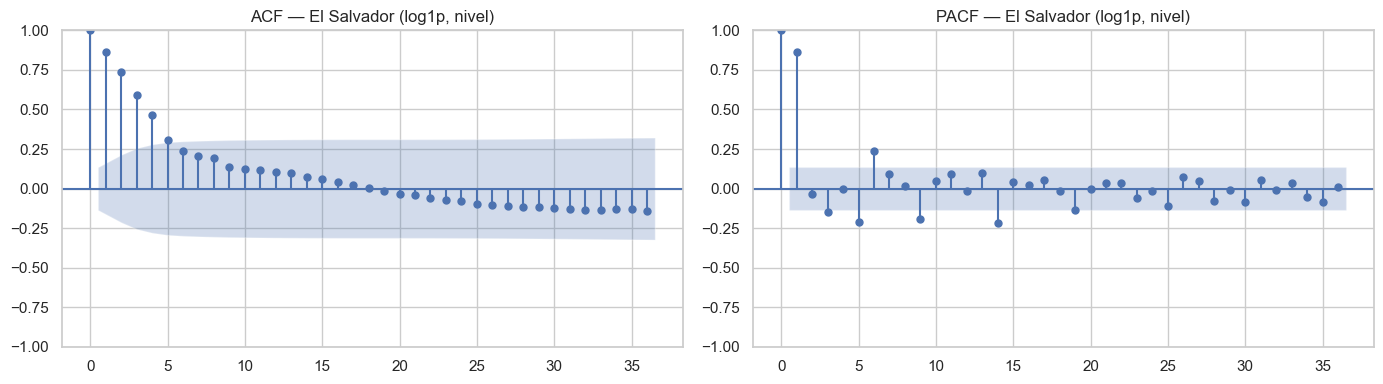

ADF  El Salvador log1p                estad= -3.030  p-valor=0.0322  -> ESTACIONARIA
KPSS El Salvador log1p                estad=  0.111  p-valor=0.1000  -> ESTACIONARIA



/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


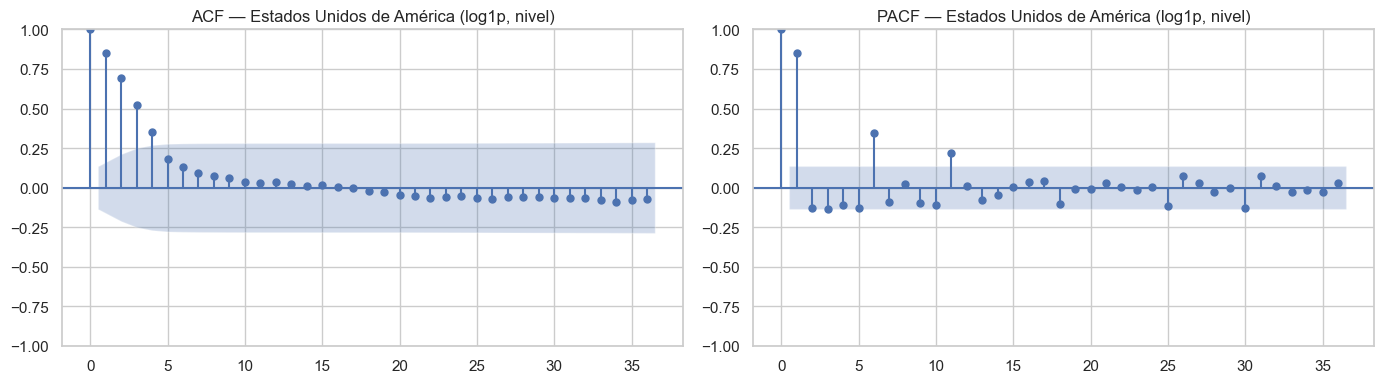

ADF  Estados Unidos de América log1p  estad= -2.966  p-valor=0.0382  -> ESTACIONARIA
KPSS Estados Unidos de América log1p  estad=  0.110  p-valor=0.1000  -> ESTACIONARIA



/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


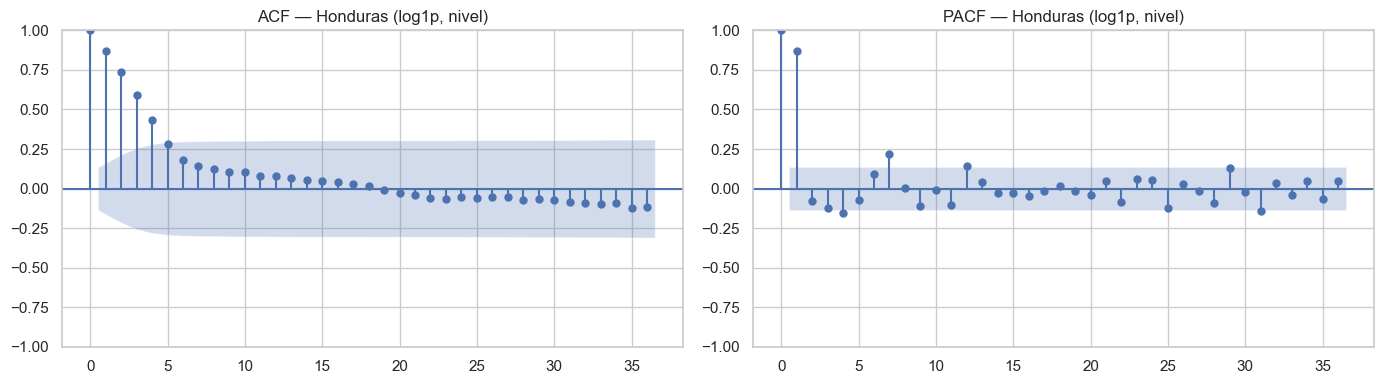

ADF  Honduras log1p                   estad= -3.126  p-valor=0.0247  -> ESTACIONARIA
KPSS Honduras log1p                   estad=  0.157  p-valor=0.1000  -> ESTACIONARIA



/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


In [10]:
for p,s_log in series_pais_log.items():
    acf_pacf(s_log,f"{p} (log1p, nivel)")
    prueba_adf(s_log,f"{p} log1p"); prueba_kpss(s_log,f"{p} log1p"); print()

**Lectura en nivel, muestra completa.** En los tres países ADF rechaza raíz unitaria (p entre 0.0247 y 0.0382) y KPSS no rechaza estacionariedad (p>0.10). Por lo tanto, estas pruebas **sí coinciden** y no corroboran una raíz unitaria en la muestra completa. Aun así, la gráfica y la descomposición muestran crecimiento antes de 2020 y un quiebre abrupto. Como ADF/KPSS suponen que no hay quiebres, añadimos al final una sensibilidad 2009–2019: sin la pandemia, ADF no rechaza raíz unitaria y KPSS rechaza estacionariedad en los tres países. Esa es la evidencia que respalda diferenciar.

### 5.1 Diferenciación regular y estacional

Aplicamos una diferencia regular (`d=1`) para quitar cambios de nivel. Para SARIMA también usaremos diferencia estacional de 12 meses (`D=1`) porque el ciclo anual sigue visible.

--- El Salvador: log1p con d=1 ---
ADF  El Salvador d=1                  estad= -4.610  p-valor=0.0001  -> ESTACIONARIA
KPSS El Salvador d=1                  estad=  0.019  p-valor=0.1000  -> ESTACIONARIA


/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


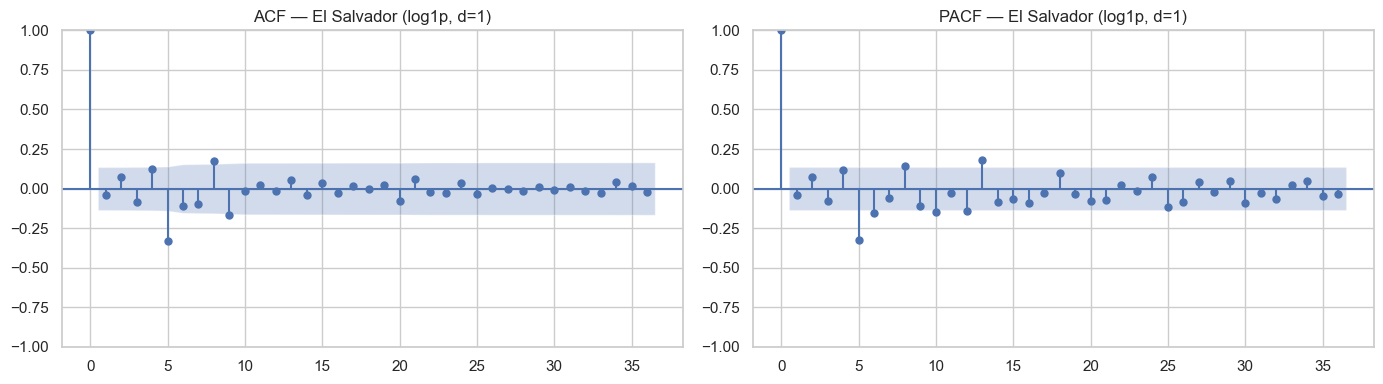

--- Estados Unidos de América: log1p con d=1 ---
ADF  Estados Unidos de América d=1    estad= -6.799  p-valor=0.0000  -> ESTACIONARIA
KPSS Estados Unidos de América d=1    estad=  0.017  p-valor=0.1000  -> ESTACIONARIA


/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


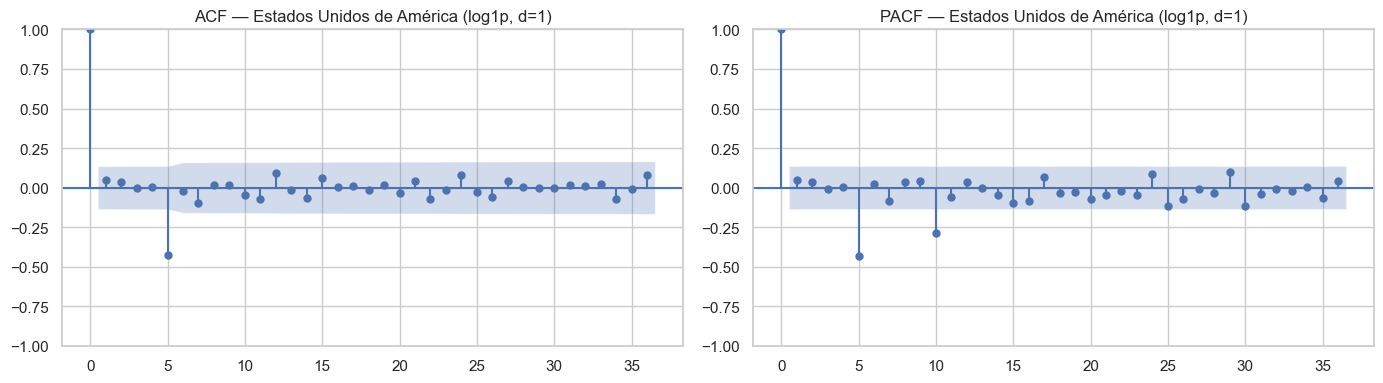

--- Honduras: log1p con d=1 ---
ADF  Honduras d=1                     estad= -5.984  p-valor=0.0000  -> ESTACIONARIA
KPSS Honduras d=1                     estad=  0.019  p-valor=0.1000  -> ESTACIONARIA


/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/28245407.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


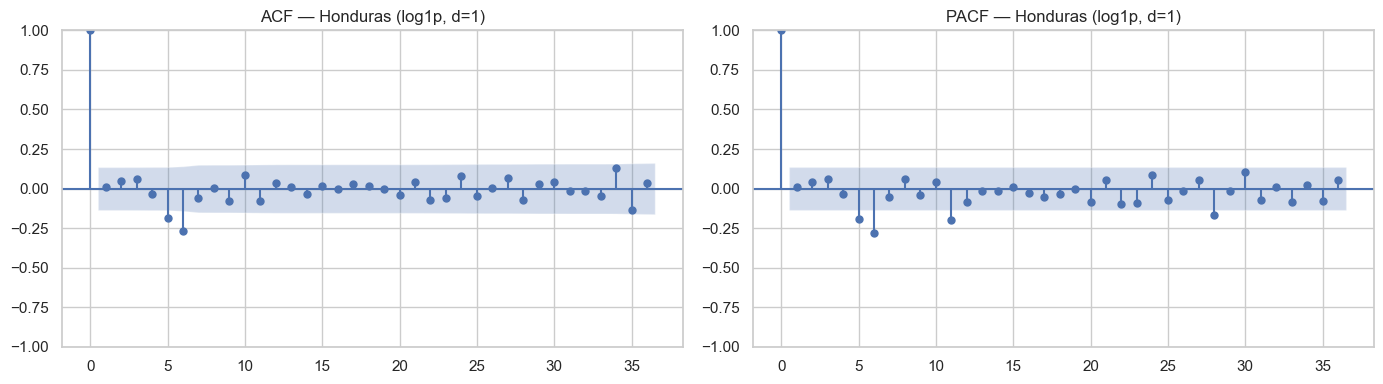

In [11]:
series_pais_d1={p:s.diff().dropna() for p,s in series_pais_log.items()}
for p,sd in series_pais_d1.items():
    print(f"--- {p}: log1p con d=1 ---")
    prueba_adf(sd,f"{p} d=1"); prueba_kpss(sd,f"{p} d=1")
    acf_pacf(sd,f"{p} (log1p, d=1)")

**Conclusión de estacionariedad.** No ocultamos la diferencia entre períodos: la muestra completa parece estacionaria según ADF/KPSS por el efecto del colapso y recuperación, pero el período pre-COVID no es estacionario y tiene media creciente. Una diferencia regular deja las series alrededor de cero; en la sensibilidad pre-COVID ADF y KPSS confirman `d=1` para El Salvador y EE. UU., mientras Honduras queda como caso limítrofe en ADF (p≈0.076) pero estacionario según KPSS. Usamos `d=1` de forma uniforme y lo contrastamos con desempeño fuera de muestra. `D` no se impondrá: lo determinará OCSB dentro de `auto_arima`.

# Parte II — Modelado y predicción por país

## 6. Partición temporal 70/30 *(Requisito 2)*

La partición no se mezcla: el primer 70 % se usa para entrenar y el último 30 % para probar. Modelamos `log1p` y regresamos a viajeros con `expm1`. Este corte termina el entrenamiento durante la pandemia, por lo que también documentaremos el efecto de este quiebre sobre el pronóstico.

In [12]:
SERIES_PAIS={p:dict(orig=s,tform=np.log1p,inv=np.expm1) for p,s in series_pais.items()}
def split_70_30(s):
    c=int(len(s)*.70); return s.iloc[:c],s.iloc[c:]
for p,d in SERIES_PAIS.items():
    d["train_o"],d["test_o"]=split_70_30(d["orig"]); d["train_t"]=d["tform"](d["train_o"])
    print(f"{p:28s} train={len(d['train_o'])} ({d['train_o'].index.min().date()} a {d['train_o'].index.max().date()}) | test={len(d['test_o'])} ({d['test_o'].index.min().date()} a {d['test_o'].index.max().date()})")

El Salvador                  train=147 (2009-01-01 a 2021-03-01) | test=63 (2021-04-01 a 2026-06-01)
Estados Unidos de América    train=147 (2009-01-01 a 2021-03-01) | test=63 (2021-04-01 a 2026-06-01)
Honduras                     train=147 (2009-01-01 a 2021-03-01) | test=63 (2021-04-01 a 2026-06-01)


## 7. Selección de órdenes ARIMA/SARIMA *(Requisito 4f)*

`p` representa rezagos autorregresivos y se orienta con PACF; `q` representa memoria de errores y se orienta con ACF; `d` es la mínima diferenciación regular. Partimos de órdenes bajos y usamos `auto_arima` como comprobación. Fijamos `d=1` según la sensibilidad pre-COVID, pero dejamos `D=None` para que la prueba OCSB decida si hace falta diferencia estacional. Una propuesta automática solo tiene sentido si además logra AIC/BIC razonables, residuos sin autocorrelación y buen error fuera de muestra.

In [13]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error,mean_squared_error

def metricas(y,p):
    return mean_absolute_error(y,p),np.sqrt(mean_squared_error(y,p))
def ajustar_sarimax(d,order,sorder=(0,0,0,0)):
    r=SARIMAX(d["train_t"],order=order,seasonal_order=sorder,enforce_stationarity=True,enforce_invertibility=True).fit(disp=False)
    pred=d["inv"](r.get_forecast(len(d["test_o"])).predicted_mean).clip(lower=0)
    mae,rmse=metricas(d["test_o"],pred)
    lb=acorr_ljungbox(r.resid.iloc[2:],lags=[12],return_df=True)["lb_pvalue"].iloc[0]
    return dict(aic=r.aic,bic=r.bic,mae=mae,rmse=rmse,lb_p=lb,pred=pred,res=r)

ordenes_auto={}; RESULTADOS_PAIS={p:{} for p in SERIES_PAIS}
for p,d in SERIES_PAIS.items():
    m=auto_arima(d["train_t"],seasonal=True,m=12,d=1,D=None,seasonal_test="ocsb",max_p=3,max_q=3,max_P=2,max_Q=2,stepwise=True,suppress_warnings=True,error_action="ignore")
    ordenes_auto[p]=(m.order,m.seasonal_order)
    print(f"{p:28s} -> SARIMA{m.order}x{m.seasonal_order}")

El Salvador                  -> SARIMA(3, 1, 1)x(0, 0, 0, 12)


Estados Unidos de América    -> SARIMA(2, 1, 2)x(0, 1, 0, 12)


Honduras                     -> SARIMA(2, 1, 2)x(1, 1, 0, 12)


## 8. Varios modelos ARIMA y diagnóstico de residuos *(Requisitos 4g y 4j)*

Comparamos la propuesta automática, ARIMA(1,1,1) sin estacionalidad y SARIMA(1,1,1)(0,1,1)12. AIC/BIC solo comparan ajuste dentro de la familia ARIMA sobre los mismos datos; MAE/RMSE evalúan el tramo de prueba. Ljung–Box contrasta ruido blanco: un p-valor mayor a 0.05 indica que no queda autocorrelación significativa al rezago 12.

In [14]:
for p,d in SERIES_PAIS.items():
    oa,sa=ordenes_auto[p]
    cand={f"auto SARIMA{oa}x{sa}":(oa,sa),"ARIMA(1,1,1) no estacional":((1,1,1),(0,0,0,0)),"SARIMA(1,1,1)(0,1,1)12":((1,1,1),(0,1,1,12))}
    for etq,(o,so) in cand.items():
        try: RESULTADOS_PAIS[p][etq]=ajustar_sarimax(d,o,so)
        except Exception as e: print(p,etq,"falló:",e)

def tabla_pais(p):
    return pd.DataFrame({e:{"AIC":r["aic"],"BIC":r["bic"],"MAE":r["mae"],"RMSE":r["rmse"],"LjungBox_p":r["lb_p"]} for e,r in RESULTADOS_PAIS[p].items()}).T.sort_values("RMSE")
for p in SERIES_PAIS:
    print(f"\n===== {p}: ARIMA/SARIMA ====="); print(tabla_pais(p).round(2).to_string())


===== El Salvador: ARIMA/SARIMA =====
                                      AIC    BIC       MAE       RMSE  LjungBox_p
ARIMA(1,1,1) no estacional         449.65 458.60 86,534.18  97,801.71        0.00
auto SARIMA(3, 1, 1)x(0, 0, 0, 12) 447.95 462.87 89,351.70 100,424.98        0.01
SARIMA(1,1,1)(0,1,1)12             427.88 439.47 95,181.47 105,708.71        0.01

===== Estados Unidos de América: ARIMA/SARIMA =====
                                      AIC    BIC       MAE      RMSE  LjungBox_p
ARIMA(1,1,1) no estacional         435.86 444.81 22,976.68 26,795.71        0.00
SARIMA(1,1,1)(0,1,1)12             407.32 418.91 34,061.01 38,272.56        0.00
auto SARIMA(2, 1, 2)x(0, 1, 0, 12) 386.70 401.19 42,383.62 58,514.03        0.18

===== Honduras: ARIMA/SARIMA =====
                                      AIC    BIC       MAE      RMSE  LjungBox_p
ARIMA(1,1,1) no estacional         387.60 396.55 14,778.75 17,193.71        0.00
SARIMA(1,1,1)(0,1,1)12             375.25 386.85 18,717.54

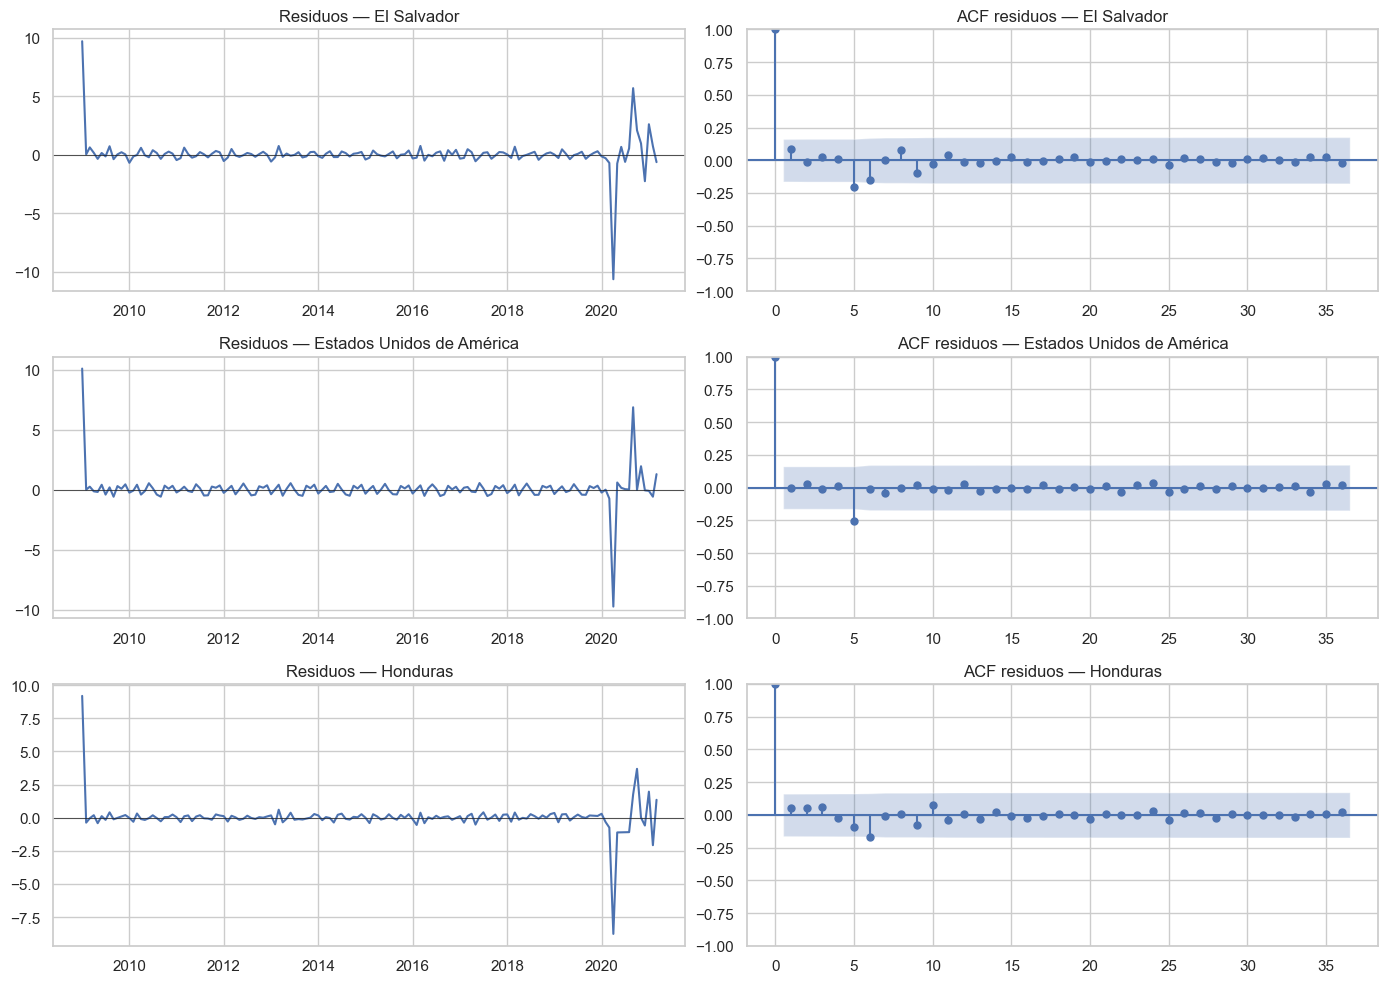

In [15]:
fig,axes=plt.subplots(3,2,figsize=(14,10))
for i,p in enumerate(SERIES_PAIS):
    mejor_ar=tabla_pais(p).index[0]; r=RESULTADOS_PAIS[p][mejor_ar]["res"]
    axes[i,0].plot(r.resid); axes[i,0].axhline(0,color="k",lw=.5); axes[i,0].set_title(f"Residuos — {p}")
    plot_acf(r.resid.dropna(),lags=36,ax=axes[i,1]); axes[i,1].set_title(f"ACF residuos — {p}")
plt.tight_layout(); plt.show()

## 9. Prophet, Holt-Winters, suavizamiento exponencial y seasonal naive *(Requisito 4h)*

Cada algoritmo usa exactamente el mismo entrenamiento y horizonte. Prophet incluye estacionalidad anual; Holt-Winters usa tendencia y estacionalidad aditivas en `log1p`; el suavizamiento exponencial simple estima solo el nivel; y seasonal naive repite los últimos 12 meses observados.

In [16]:
import logging
for lg in ["prophet","cmdstanpy"]: logging.getLogger(lg).setLevel(logging.ERROR)
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing,SimpleExpSmoothing
def pred_prophet(d):
    m=Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
    m.fit(pd.DataFrame({"ds":d["train_t"].index,"y":d["train_t"].values}))
    z=m.predict(pd.DataFrame({"ds":d["test_o"].index}))["yhat"].values
    return pd.Series(d["inv"](z),index=d["test_o"].index).clip(lower=0)
def pred_hw(d):
    m=ExponentialSmoothing(d["train_t"],trend="add",seasonal="add",seasonal_periods=12).fit()
    return pd.Series(d["inv"](np.asarray(m.forecast(len(d["test_o"])))),index=d["test_o"].index).clip(lower=0)
def pred_ses(d):
    m=SimpleExpSmoothing(d["train_t"]).fit(); return pd.Series(d["inv"](np.asarray(m.forecast(len(d["test_o"])))),index=d["test_o"].index).clip(lower=0)
def pred_sn(d):
    u=d["train_o"].iloc[-12:].values; return pd.Series([u[i%12] for i in range(len(d["test_o"]))],index=d["test_o"].index)
for p,d in SERIES_PAIS.items():
    for etq,fn in {"Prophet":pred_prophet,"Holt-Winters":pred_hw,"Suav.Exp.Simple":pred_ses,"Seasonal Naive":pred_sn}.items():
        pr=fn(d); mae,rmse=metricas(d["test_o"],pr)
        RESULTADOS_PAIS[p][etq]=dict(aic=np.nan,bic=np.nan,mae=mae,rmse=rmse,lb_p=np.nan,pred=pr)
print("Modelos alternativos ajustados.")

Importing plotly failed. Interactive plots will not work.


10:47:41 - cmdstanpy - INFO - Chain [1] start processing


10:47:41 - cmdstanpy - INFO - Chain [1] done processing


10:47:41 - cmdstanpy - INFO - Chain [1] start processing


10:47:41 - cmdstanpy - INFO - Chain [1] done processing


10:47:41 - cmdstanpy - INFO - Chain [1] start processing


10:47:41 - cmdstanpy - INFO - Chain [1] done processing


Modelos alternativos ajustados.


## 10. Comparación, predicción y selección *(Requisitos 4i, 4j y 4k)*

El criterio principal será RMSE fuera de muestra, con MAE como apoyo. No usamos AIC/BIC para comparar Prophet o suavizamientos porque no son métricas equivalentes entre estas implementaciones.

In [17]:
mejores_pais={}
for p in SERIES_PAIS:
    t=tabla_pais(p); mejores_pais[p]=t.index[0]
    print(f"\n===== {p} -> mejor por RMSE: {t.index[0]} ====="); print(t.round(2).to_string())


===== El Salvador -> mejor por RMSE: Suav.Exp.Simple =====
                                      AIC    BIC       MAE       RMSE  LjungBox_p
Suav.Exp.Simple                       NaN    NaN 81,334.44  92,859.87         NaN
ARIMA(1,1,1) no estacional         449.65 458.60 86,534.18  97,801.71        0.00
Holt-Winters                          NaN    NaN 86,862.28  97,871.32         NaN
auto SARIMA(3, 1, 1)x(0, 0, 0, 12) 447.95 462.87 89,351.70 100,424.98        0.01
Seasonal Naive                        NaN    NaN 91,662.09 102,198.52         NaN
Prophet                               NaN    NaN 92,241.77 103,457.93         NaN
SARIMA(1,1,1)(0,1,1)12             427.88 439.47 95,181.47 105,708.71        0.01

===== Estados Unidos de América -> mejor por RMSE: ARIMA(1,1,1) no estacional =====
                                      AIC    BIC       MAE      RMSE  LjungBox_p
ARIMA(1,1,1) no estacional         435.86 444.81 22,976.68 26,795.71        0.00
Suav.Exp.Simple                      

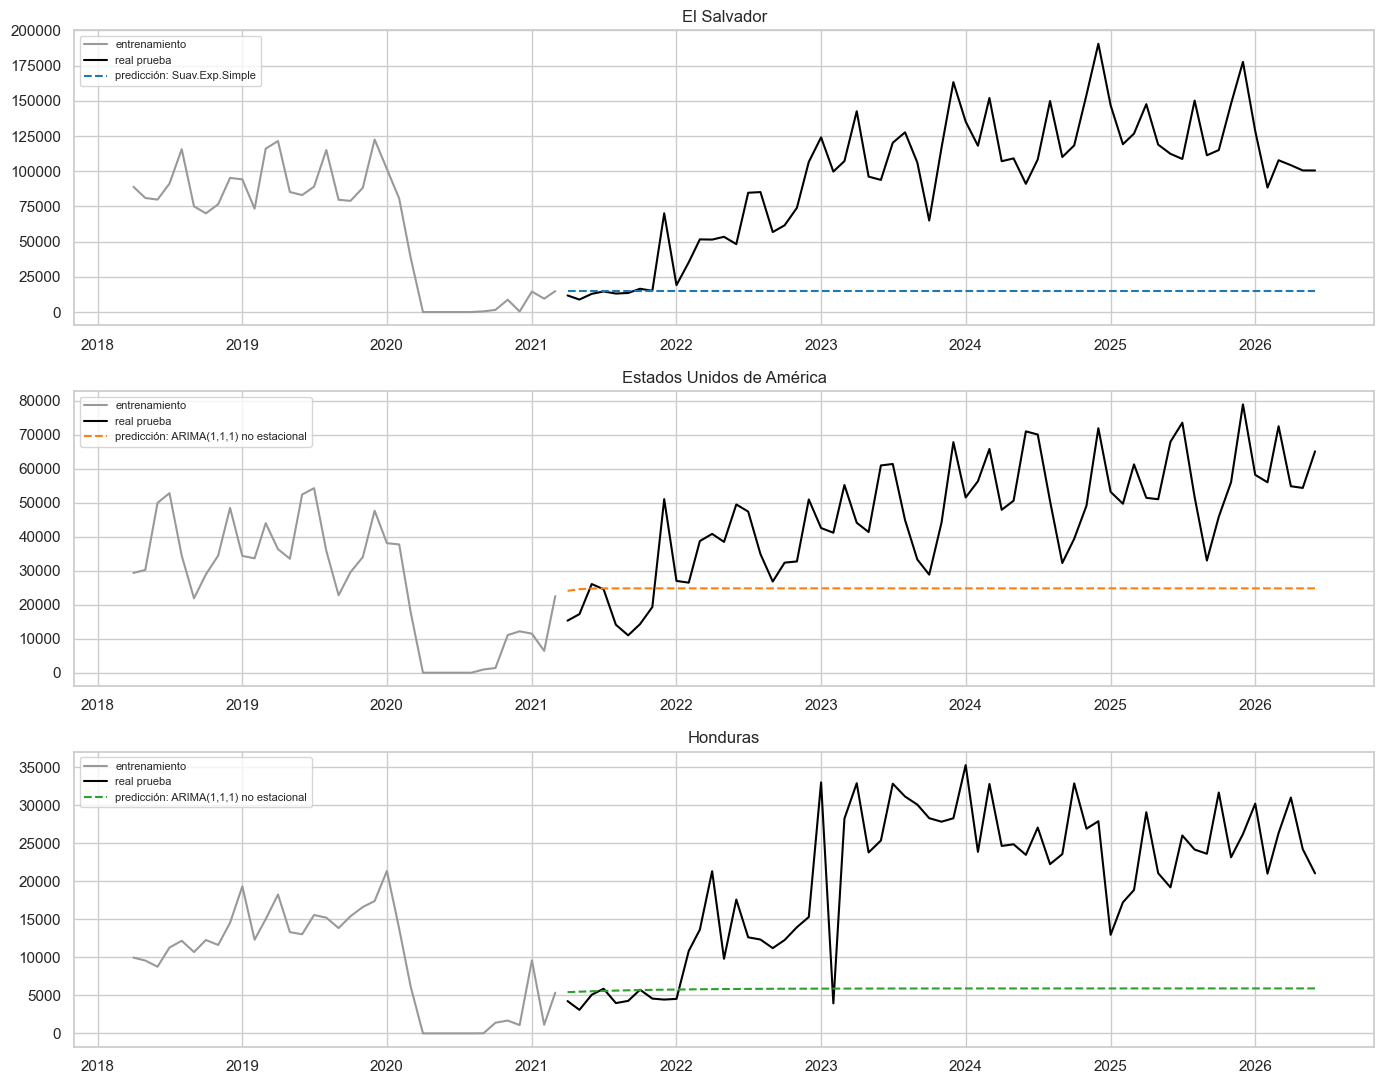

In [18]:
fig,axes=plt.subplots(3,1,figsize=(14,11),sharex=False)
for ax,(p,d) in zip(axes,SERIES_PAIS.items()):
    best=mejores_pais[p]; pr=RESULTADOS_PAIS[p][best]["pred"]
    ax.plot(d["train_o"].iloc[-36:],color="#999",label="entrenamiento")
    ax.plot(d["test_o"],color="black",label="real prueba")
    ax.plot(pr,color=colores[p],ls="--",label=f"predicción: {best}")
    ax.set_title(p); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 11. Conclusiones del modelado por país

- **El Salvador:** el mejor modelo para el test 70/30 es el **suavizamiento exponencial simple**, con MAE **81,334** y RMSE **92,860** viajeros.
- **Estados Unidos:** gana **ARIMA(1,1,1)**, con MAE **22,977** y RMSE **26,796**.
- **Honduras:** también gana **ARIMA(1,1,1)**, con MAE **14,779** y RMSE **17,194**.

`auto_arima` selecciona `D=0` para El Salvador y `D=1` para Estados Unidos y Honduras mediante OCSB. Sus órdenes más altos suelen reducir AIC/BIC, pero no ganan el test. El entrenamiento termina en marzo de 2021 y el test contiene la recuperación; en este quiebre, los modelos complejos extrapolan mal el régimen deprimido. Por eso seleccionamos con RMSE fuera de muestra, sin afirmar que los residuos sean perfectos. La Parte IV muestra autocorrelación pendiente en algunos ganadores, una limitación importante.

El resultado no significa que la estacionalidad sea inexistente: para este corte excepcional y un horizonte de 63 meses, un modelo parsimonioso tolera mejor el cambio estructural. Las gráficas anteriores comparan la predicción con los valores reales del conjunto de prueba.

# Parte III — Análisis comparativo *(Ejercicio 5)*

Para responder con evidencia estadística usamos cuatro indicadores calculados de la misma forma para todas las series:

1. **Fuerza estacional** de Hyndman: `max(0, 1 - Var(residuo) / Var(estacional + residuo))`, entre 0 y 1. Se calcula con datos pre-pandemia para que el cierre no domine la descomposición.
2. **Crecimiento anual pre-pandemia:** pendiente de una regresión lineal de `log1p(serie)` contra tiempo entre 2009 y 2019, convertida a porcentaje anual.
3. **Volatilidad residual:** desviación estándar del residuo de la descomposición de `log1p` entre 2009 y 2019, después de retirar tendencia y estacionalidad. Al ser relativa permite comparar tamaños distintos sin contar el ciclo regular como volatilidad.
4. **Impacto pandémico:** caída porcentual de abril-diciembre de 2020 respecto a los mismos meses de 2019. Así no se diluye el cierre con enero-marzo, que todavía fueron meses normales.

Estas definiciones evitan confundir mayor volumen con mayor estacionalidad, crecimiento o volatilidad.

In [19]:
# Reconstrucción de Total y Vías con las definiciones documentadas en el Notebook 1
base_te=df[df["Tipo de Viajero"].isin(["Turista","Excursionista"])]
serie_total_cmp=base_te.groupby("Fecha")["Viajero"].sum().asfreq("MS")
serie_aerea_cmp=base_te[base_te["Vía"]=="Aérea"].groupby("Fecha")["Viajero"].sum().asfreq("MS")
serie_terrestre_cmp=base_te[base_te["Vía"]=="Terrestre"].groupby("Fecha")["Viajero"].sum().asfreq("MS")
rango_mar=pd.date_range("2009-01-01","2022-12-01",freq="MS")
serie_maritima_cmp=(df[(df["Vía"]=="Marítima")&(df["Tipo de Viajero"]=="Cruceristas")].groupby("Fecha")["Viajero"].sum().reindex(rango_mar).fillna(0).asfreq("MS"))

CATEGORIAS={
 "Vías":{"Aérea":serie_aerea_cmp,"Terrestre":serie_terrestre_cmp,"Marítima":serie_maritima_cmp},
 "Países":series_pais
}

def indicadores(s):
    pre=s.loc["2009":"2019"]
    z=np.log1p(pre)
    dec=seasonal_decompose(z,model="additive",period=12)
    ok=dec.resid.notna(); resid=dec.resid[ok]; est=dec.seasonal[ok]
    fuerza=max(0,1-np.var(resid)/np.var(resid+est))
    x=np.arange(len(z)); pendiente=np.polyfit(x,z.values,1)[0]
    crec=(np.exp(12*pendiente)-1)*100
    vol=resid.std()
    y19=s[(s.index.year==2019)&(s.index.month>=4)].sum()
    y20=s[(s.index.year==2020)&(s.index.month>=4)].sum()
    impacto=(1-y20/y19)*100
    return {"Fuerza estacional":fuerza,"Crecimiento anual pre-COVID (%)":crec,"Volatilidad residual log":vol,"Caída abr-dic 2020 vs 2019 (%)":impacto}

tablas_comparativas={}
for cat,ss in CATEGORIAS.items():
    t=pd.DataFrame({nom:indicadores(s) for nom,s in ss.items()}).T
    tablas_comparativas[cat]=t
    print(f"\n===== {cat} ====="); print(t.round(3).to_string())

print("\n===== Total obligatorio (referencia general) =====")
print(pd.Series(indicadores(serie_total_cmp)).round(3).to_string())


===== Vías =====
           Fuerza estacional  Crecimiento anual pre-COVID (%)  Volatilidad residual log  Caída abr-dic 2020 vs 2019 (%)
Aérea                   0.90                             5.16                      0.04                           90.71
Terrestre               0.68                            11.16                      0.10                           95.34
Marítima                0.63                            16.66                      2.01                          100.00

===== Países =====
                           Fuerza estacional  Crecimiento anual pre-COVID (%)  Volatilidad residual log  Caída abr-dic 2020 vs 2019 (%)
El Salvador                             0.57                            11.97                      0.14                           98.70
Estados Unidos de América               0.94                             4.29                      0.07                           92.61
Honduras                                0.54                             4

## 12. Resultados por categoría

Las tablas anteriores son la evidencia para responder cuál serie ocupa el primer lugar en cada criterio. La fuerza estacional y la volatilidad no tienen unidades; crecimiento e impacto están expresados en porcentaje.

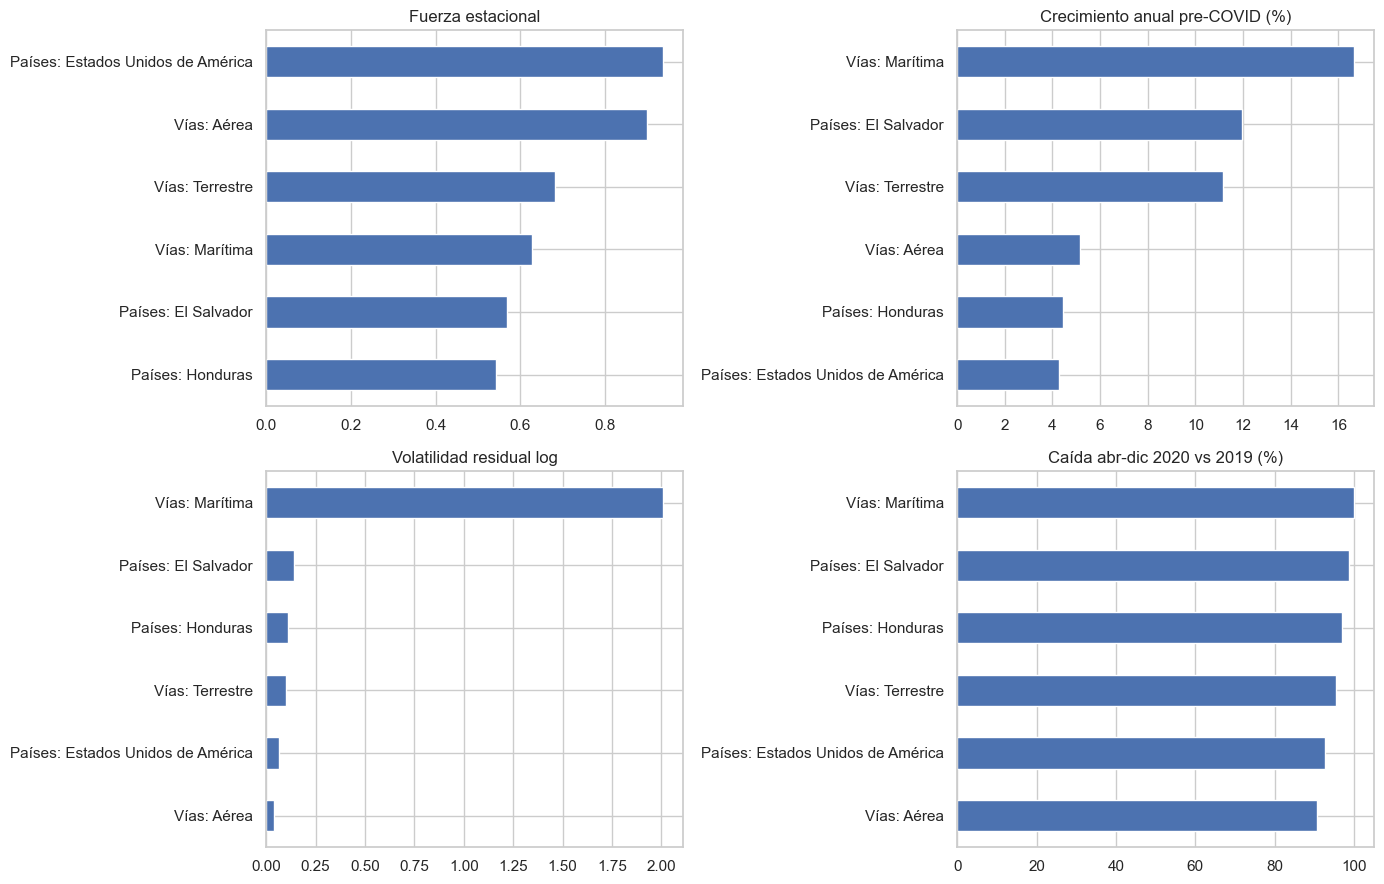

In [20]:
fig,axes=plt.subplots(2,2,figsize=(14,9))
metricas_cmp=list(next(iter(tablas_comparativas.values())).columns)
for ax,m in zip(axes.ravel(),metricas_cmp):
    partes=[]
    for cat,t in tablas_comparativas.items():
        q=t[[m]].copy(); q["Serie"]=[f"{cat}: {x}" for x in q.index]; partes.append(q.set_index("Serie"))
    pd.concat(partes)[m].sort_values().plot(kind="barh",ax=ax,color="#4c72b0")
    ax.set_title(m); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 13. Respuestas del análisis comparativo *(Requisito 5a)*

### Vías de ingreso

1. **Mayor estacionalidad: Aérea**, con fuerza estacional **0.90**, frente a 0.68 de Terrestre y 0.63 de Marítima. Aunque los cruceros tienen una temporada muy clara, sus ceros e intermitencia también aumentan el residuo y reducen este indicador.
2. **Mayor tendencia de crecimiento: Marítima**, con crecimiento estimado pre-COVID de **16.66 % anual**; le sigue Terrestre con 11.16 % y Aérea con 5.16 %. Este resultado debe interpretarse con precaución por el bajo volumen y la intermitencia de Marítima.
3. **Mayor volatilidad: Marítima**, con desviación residual log **2.01**, superior a Terrestre (0.10) y Aérea (0.04). Aun después de retirar el ciclo regular, los cambios entre meses con y sin cruceros dejan mucha variación no explicada.
4. **Mayor afectación pandémica: Marítima**, con caída de **100 %** entre abril-diciembre de 2020 frente al mismo período de 2019. Terrestre cayó 95.34 % y Aérea 90.71 %.

### Países de residencia

1. **Mayor estacionalidad: Estados Unidos**, con fuerza **0.94**, muy por encima de El Salvador (0.57) y Honduras (0.54).
2. **Mayor tendencia de crecimiento: El Salvador**, con **11.97 % anual** antes de la pandemia; Honduras y Estados Unidos crecían alrededor de 4.43 % y 4.29 %.
3. **Mayor volatilidad residual: El Salvador**, con desviación log **0.142**, seguido por Honduras (0.109) y Estados Unidos (0.065). Al retirar la estacionalidad, Estados Unidos deja de ser el más volátil: gran parte de sus cambios mensuales eran regulares y predecibles.
4. **Mayor afectación pandémica: El Salvador**, con caída de **98.70 %** en abril-diciembre de 2020. Honduras cayó 96.97 % y Estados Unidos 92.61 %.

Como referencia, la serie Total tiene fuerza estacional 0.79, crecimiento pre-COVID de 8.45 % anual y volatilidad 0.20. Su caída abril-diciembre se muestra en la tabla ejecutada.

## 14. Descubrimientos útiles para el INGUAT *(Requisito 5b)*

Los hallazgos que considero más útiles para decisiones son los siguientes:

- **Planificar por temporada y mercado.** La fuerza estacional de Estados Unidos (0.94) y de la vía Aérea (0.90) permite anticipar meses altos y coordinar campañas, conectividad aérea y capacidad de atención. No conviene distribuir el presupuesto de promoción de manera uniforme durante el año.
- **Cuidar el turismo regional terrestre.** El Salvador era el mercado con mayor crecimiento pre-pandemia (11.97 % anual) y la vía Terrestre crecía 11.16 %. Además, Terrestre concentra la mayoría de viajeros según el EDA. Facilitar pasos fronterizos y campañas regionales puede tener un impacto grande en volumen.
- **Tener planes de contingencia distintos por vía.** Entre abril y diciembre de 2020 Marítima cayó 100 %, Terrestre 95.34 % y Aérea 90.71 %. Una crisis no afecta igual a todos los canales; conviene monitorear y pronosticar cada vía por separado.
- **No usar un solo pronóstico de largo plazo después de un quiebre.** El test 70/30 empieza cerca del piso pandémico y todos los modelos tienen errores altos durante la recuperación. Para decisiones operativas usaría reentrenamiento frecuente, horizontes cortos e intervalos de incertidumbre, en vez de fijar un plan de cinco años con un modelo entrenado durante una crisis.
- **Mantener consistencia metodológica.** El cambio de clasificación desde 2023 puede confundirse con una caída real. Para tableros históricos se debe conservar la definición consistente `Turista + Excursionista` y señalar claramente la serie Marítima, que termina en 2022 bajo la definición de cruceristas.

En síntesis, el análisis sirve más para identificar **cuándo, por dónde y desde qué mercados** llega la demanda, además de reconocer cuándo un quiebre hace que un modelo histórico deje de ser confiable.

# Parte IV — Verificación explícita de la rúbrica

Esta parte reúne las comprobaciones que deben quedar claras **para cada una de las siete series**. También corrige una posible lectura engañosa: ADF/KPSS sobre toda la muestra pueden clasificar como estacionaria una serie que contiene un crecimiento y luego un colapso estructural. Por eso mostramos la sensibilidad pre-COVID, sin usarla para entrenar los pronósticos.

## 15. Sensibilidad de estacionariedad antes del quiebre

En ADF, p<0.05 rechaza raíz unitaria; en KPSS, p<0.05 rechaza estacionariedad. Evaluamos nivel transformado y una diferencia en 2009–2019. La cantidad correcta de diferencias es la mínima que deja una serie estacionaria.

In [21]:
from pmdarima.arima.utils import nsdiffs
# Siete series y transformaciones usadas en el análisis
SERIES_AUD={
 "Total":(serie_total_cmp,np.log),"Aérea":(serie_aerea_cmp,np.log),
 "Terrestre":(serie_terrestre_cmp,np.log),"Cruceristas marítimos":(serie_maritima_cmp,np.log1p),
 **{p:(s,np.log1p) for p,s in series_pais.items()}
}
filas=[]
for nom,(s,tf) in SERIES_AUD.items():
    pre=tf(s.loc[:"2019-12-01"]); d1=pre.diff().dropna()
    filas.append({"Serie":nom,"ADF nivel p":adfuller(pre,autolag="AIC")[1],
                  "KPSS nivel p":kpss(pre,regression="c",nlags="auto")[1],
                  "ADF d=1 p":adfuller(d1,autolag="AIC")[1],
                  "KPSS d=1 p":kpss(d1,regression="c",nlags="auto")[1]})
tabla_estacionariedad=pd.DataFrame(filas).set_index("Serie")
tabla_estacionariedad.round(4)

/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/2857428074.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  "KPSS nivel p":kpss(pre,regression="c",nlags="auto")[1],
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/2857428074.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  "KPSS d=1 p":kpss(d1,regression="c",nlags="auto")[1]})
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/2857428074.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  "KPSS nivel p":kpss(pre,regression="c",nlags="auto")[1],
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_2423/2857428074.py:

,ADF nivel p,KPSS nivel p,ADF d=1 p,KPSS d=1 p
Serie,,,,
Total,1.00,0.01,0.00,0.10
Aérea,0.99,0.01,0.00,0.10
Terrestre,0.99,0.01,0.00,0.10
Cruceristas marítimos,0.27,0.10,0.00,0.04
El Salvador,0.95,0.01,0.00,0.10
Estados Unidos de América,1.00,0.01,0.00,0.10
Honduras,0.91,0.01,0.08,0.10


**Conclusión.** Para seis series, la sensibilidad pre-COVID respalda con claridad una media no estacionaria y `d=1`. **Cruceristas marítimos es un caso mixto**: en nivel ADF no rechaza raíz unitaria (p≈0.27), pero KPSS tampoco rechaza estacionariedad; después de `d=1`, ADF rechaza la raíz y KPSS queda apenas debajo de 0.05 debido a intermitencia y estacionalidad extrema. En la muestra completa del Notebook 1 ambas pruebas sí clasifican la Marítima diferenciada como estacionaria. Adoptamos `d=1`, dejando documentada esta incertidumbre. Honduras también es limítrofe en ADF después de diferenciar (p≈0.076), aunque KPSS y la muestra completa apoyan estacionariedad.

## 16. Explicación de `p`, `q`, `d` y propuestas automáticas

- **`p`** cuenta rezagos autorregresivos: PACF ayuda a detectar si el valor actual depende directamente de meses anteriores.
- **`q`** cuenta rezagos del error: ACF ayuda a detectar cuánto duran los choques no explicados.
- **`d=1`** es la diferencia regular respaldada por la tabla anterior.
- **`P,D,Q`** son equivalentes estacionales a 12 meses. OCSB determina `D`; así no se impone una diferencia estacional solo porque existe un ciclo.

La tabla siguiente resume cómo se interpreta cada propuesta. Un orden automático minimiza AIC durante entrenamiento; no tiene obligación de ganar el test ni de ser el modelo final.

In [22]:
ordenes_todas={
 "Total":((2,1,2),(2,0,0,12)),"Aérea":((0,1,0),(1,0,1,12)),
 "Terrestre":((2,1,2),(2,0,0,12)),"Cruceristas marítimos":((0,1,1),(1,0,1,12)),
 **{p:ordenes_auto[p] for p in series_pais}
}
lectura={
 "Total":"ACF/PACF cortas sin corte claro; se contrastan órdenes bajos. Auto agrega AR/MA y P=2, pero no mejora RMSE.",
 "Aérea":"ACF/PACF cortas débiles; p=q=0 es parsimonioso. P=Q=1 representa dependencia anual sin D.",
 "Terrestre":"ACF y PACF tienen señal en lag 1; ARIMA(1,1,1) es candidato natural. Auto más complejo no mejora test.",
 "Cruceristas marítimos":"ACF/PACF fuertes en lag 1 y lags anuales; MA(1), P=Q=1 tiene sentido, aunque SES gana RMSE.",
 "El Salvador":"No hay corte corto limpio; auto elige AR(3), MA(1), D=0. Su complejidad no compensa en prueba.",
 "Estados Unidos de América":"Pico común cerca del lag 5 y señal anual; auto usa p=q=2 y D=1, con menor AIC pero peor RMSE.",
 "Honduras":"Señal de corto plazo y anual; auto usa p=q=2, P=D=1, pero ARIMA(1,1,1) generaliza mejor."}
filas=[]
for nom,(s,tf) in SERIES_AUD.items():
    tr=tf(s.iloc[:int(len(s)*.70)]); D=nsdiffs(tr,m=12,max_D=1,test="ocsb")
    o,so=ordenes_todas[nom]
    filas.append({"Serie":nom,"d":1,"D (OCSB)":D,"Orden auto":str(o),"Orden estacional":str(so),"Lectura ACF/PACF y decisión":lectura[nom]})
tabla_ordenes=pd.DataFrame(filas).set_index("Serie")
pd.set_option("display.max_colwidth",120)
tabla_ordenes

,d,D (OCSB),Orden auto,Orden estacional,Lectura ACF/PACF y decisión
Serie,,,,,
Total,1,0,"(2, 1, 2)","(2, 0, 0, 12)","ACF/PACF cortas sin corte claro; se contrastan órdenes bajos. Auto agrega AR/MA y P=2, pero no mejora RMSE."
Aérea,1,0,"(0, 1, 0)","(1, 0, 1, 12)",ACF/PACF cortas débiles; p=q=0 es parsimonioso. P=Q=1 representa dependencia anual sin D.
Terrestre,1,0,"(2, 1, 2)","(2, 0, 0, 12)","ACF y PACF tienen señal en lag 1; ARIMA(1,1,1) es candidato natural. Auto más complejo no mejora test."
Cruceristas marítimos,1,0,"(0, 1, 1)","(1, 0, 1, 12)","ACF/PACF fuertes en lag 1 y lags anuales; MA(1), P=Q=1 tiene sentido, aunque SES gana RMSE."
El Salvador,1,0,"(3, 1, 1)","(0, 0, 0, 12)","No hay corte corto limpio; auto elige AR(3), MA(1), D=0. Su complejidad no compensa en prueba."
Estados Unidos de América,1,1,"(2, 1, 2)","(0, 1, 0, 12)","Pico común cerca del lag 5 y señal anual; auto usa p=q=2 y D=1, con menor AIC pero peor RMSE."
Honduras,1,1,"(2, 1, 2)","(1, 1, 0, 12)","Señal de corto plazo y anual; auto usa p=q=2, P=D=1, pero ARIMA(1,1,1) generaliza mejor."


**Decisión sobre los parámetros.** ARIMA(1,1,1) se mantiene como candidato común porque representa, con el mínimo de complejidad, una dependencia de un mes (`p=1`) y un choque de un mes (`q=1`) después de diferenciar. Las propuestas automáticas se aceptan como candidatos cuando su estructura coincide con señales anuales, pero se rechazan como modelo final si el RMSE es peor. En especial, los órdenes altos de Total, Terrestre y los países reducen AIC sin mejorar el horizonte largo; es una señal de ajuste excesivo al entrenamiento y al quiebre.

## 17. Residuos de los siete modelos seleccionados

Los residuos se calculan en la escala transformada de entrenamiento. Revisamos media cercana a cero, ACF y Ljung–Box en 12 y 24 meses. Un p-valor menor a 0.05 indica autocorrelación pendiente.

                          Modelo  Media residuo  LB p(12)  LB p(24)
Serie                                                              
Total                      ARIMA          -0.00      0.08      0.01
Aérea                      ARIMA          -0.00      0.07      0.49
Terrestre                    SES          -0.01      0.00      0.00
Cruceristas marítimos        SES          -0.21      0.00      0.00
El Salvador                  SES          -0.00      0.00      0.04
Estados Unidos de América  ARIMA           0.00      0.00      0.08
Honduras                   ARIMA          -0.04      0.00      0.20


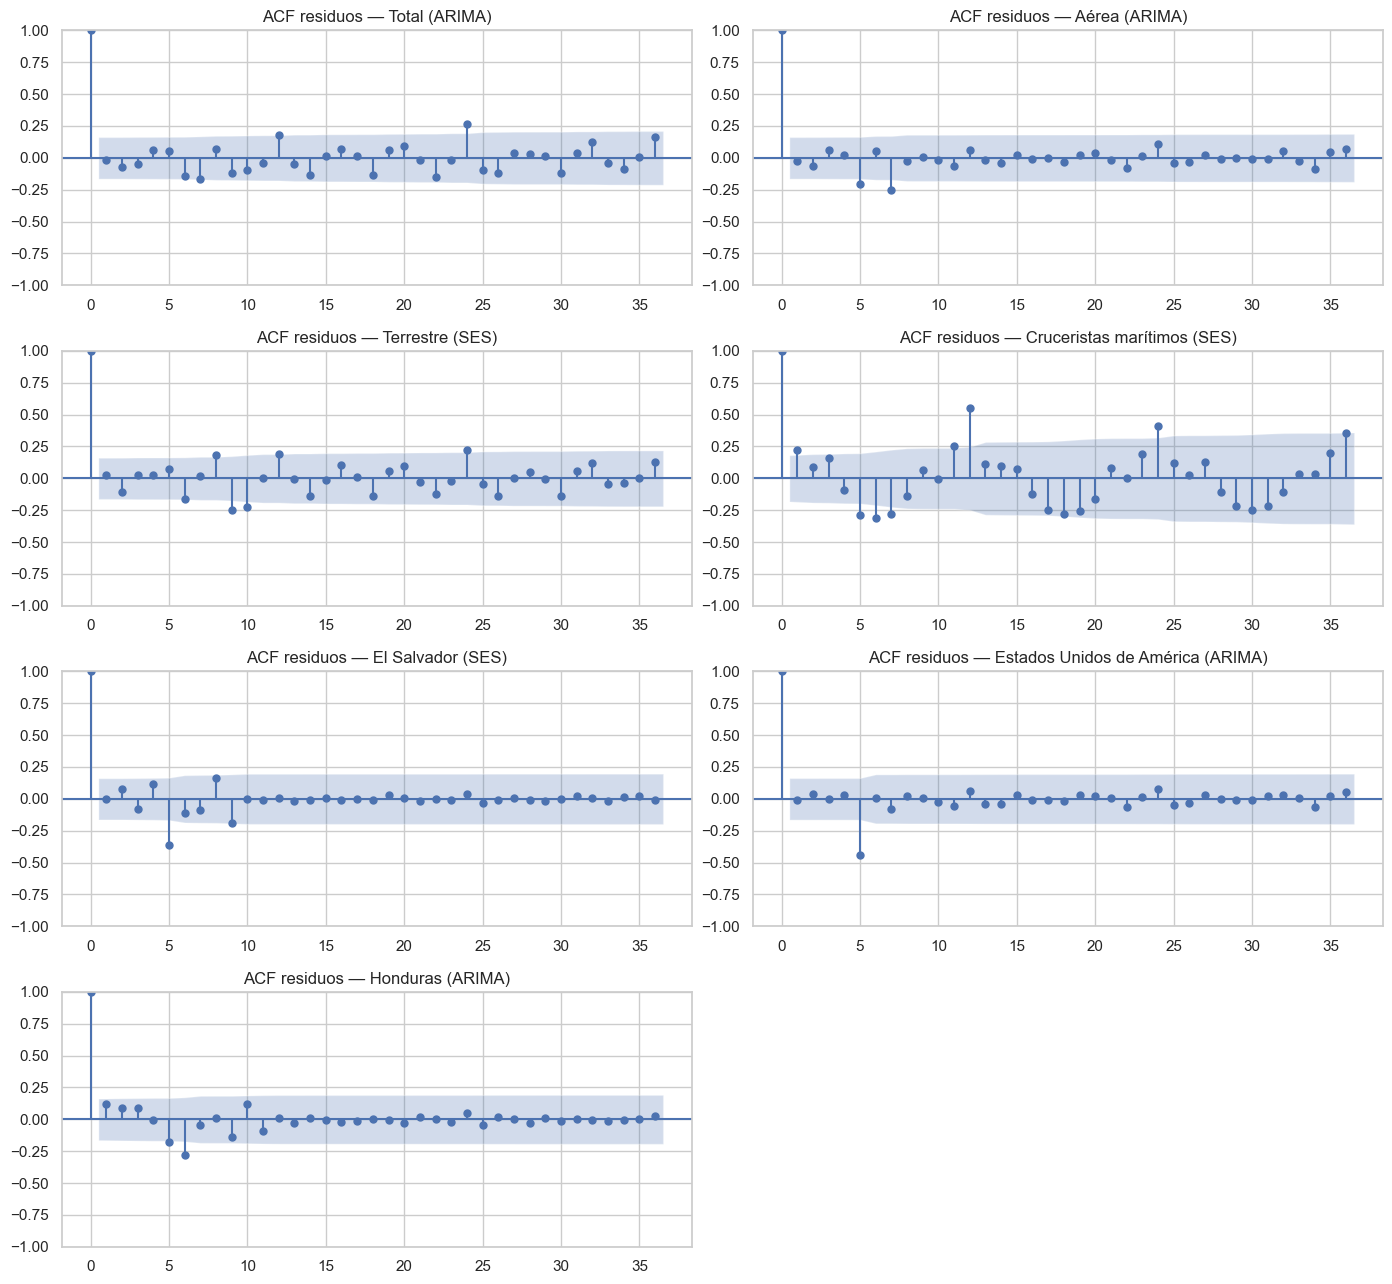

In [23]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
seleccion={"Total":"ARIMA","Aérea":"ARIMA","Terrestre":"SES","Cruceristas marítimos":"SES",
           "El Salvador":"SES","Estados Unidos de América":"ARIMA","Honduras":"ARIMA"}
residuos_sel={}; diag=[]
for nom,(s,tf) in SERIES_AUD.items():
    tr=tf(s.iloc[:int(len(s)*.70)])
    if seleccion[nom]=="ARIMA":
        mod=SARIMAX(tr,order=(1,1,1),seasonal_order=(0,0,0,0),enforce_stationarity=True,enforce_invertibility=True).fit(disp=False)
        resid=mod.resid.iloc[2:]
    else:
        mod=SimpleExpSmoothing(tr).fit(); resid=(tr-mod.fittedvalues).dropna()
    residuos_sel[nom]=resid
    lb=acorr_ljungbox(resid,lags=[12,24],return_df=True)
    diag.append({"Serie":nom,"Modelo":seleccion[nom],"Media residuo":resid.mean(),"LB p(12)":lb.loc[12,"lb_pvalue"],"LB p(24)":lb.loc[24,"lb_pvalue"]})
tabla_residuos=pd.DataFrame(diag).set_index("Serie")
print(tabla_residuos.round(4).to_string())
fig,axes=plt.subplots(4,2,figsize=(14,13))
for ax,(nom,resid) in zip(axes.ravel(),residuos_sel.items()):
    plot_acf(resid,lags=36,ax=ax); ax.set_title(f"ACF residuos — {nom} ({seleccion[nom]})")
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()

**Lectura de residuos.** Aérea es el diagnóstico más favorable: Ljung–Box no rechaza en 12 ni 24 meses. Total pasa al rezago 12 pero falla en 24, por lo que conserva memoria de largo plazo. Los SES de Terrestre, Cruceristas marítimos y El Salvador fallan Ljung–Box; fueron seleccionados por RMSE, no porque expliquen toda la estructura temporal. Los ARIMA de Estados Unidos y Honduras también dejan señal estacional al rezago 12. En consecuencia, los ganadores son útiles como comparación predictiva del test, pero **no todos producen ruido blanco**; para operación real se recomendaría modelar intervenciones de pandemia y reentrenar con datos recientes.

## 18. Calidad predictiva relativa en el test 70/30

MAE y RMSE dependen del tamaño de la serie. Para decir qué tan bueno es cada ganador, agregamos RMSE como porcentaje de la media del test y mejora frente a seasonal naive. Una mejora grande indica valor predictivo sobre repetir el último año; una mejora pequeña significa que el modelo apenas supera esa línea base.

In [24]:
def evaluar_seleccion(nom,s,tf):
    c=int(len(s)*.70); tro,te=s.iloc[:c],s.iloc[c:]; tr=tf(tro)
    if seleccion[nom]=="ARIMA":
        m=SARIMAX(tr,order=(1,1,1),seasonal_order=(0,0,0,0),enforce_stationarity=True,enforce_invertibility=True).fit(disp=False)
        pt=m.get_forecast(len(te)).predicted_mean
    else:
        m=SimpleExpSmoothing(tr).fit(); pt=m.forecast(len(te))
    inv=np.expm1 if tf is np.log1p else np.exp
    pred=pd.Series(inv(np.asarray(pt)),index=te.index).clip(lower=0)
    naive=pd.Series([tro.iloc[-12:].values[i%12] for i in range(len(te))],index=te.index)
    mae=np.mean(np.abs(te-pred)); rmse=np.sqrt(np.mean((te-pred)**2)); rn=np.sqrt(np.mean((te-naive)**2))
    return {"Modelo":seleccion[nom],"MAE":mae,"RMSE":rmse,"RMSE / media test (%)":100*rmse/te.mean(),
            "RMSE seasonal naive":rn,"Mejora vs naive (%)":100*(1-rmse/rn)}
calidad=[]
for nom,(s,tf) in SERIES_AUD.items(): calidad.append({"Serie":nom,**evaluar_seleccion(nom,s,tf)})
tabla_calidad=pd.DataFrame(calidad).set_index("Serie")
tabla_calidad.round(2)

,Modelo,MAE,RMSE,RMSE / media test (%),RMSE seasonal naive,Mejora vs naive (%)
Serie,,,,,,
Total,ARIMA,"154,494.17","169,119.58",69.99,"219,663.87",23.01
Aérea,ARIMA,"33,225.80","38,374.56",40.79,"79,339.80",51.63
Terrestre,SES,"122,392.66","134,835.59",91.39,"144,274.98",6.54
Cruceristas marítimos,SES,"5,341.82","8,082.40",160.84,"11,822.39",31.63
El Salvador,SES,"81,334.44","92,859.87",97.09,"102,198.52",9.14
Estados Unidos de América,ARIMA,"22,976.68","26,795.71",58.28,"43,733.36",38.73
Honduras,ARIMA,"14,778.75","17,193.71",85.02,"20,918.17",17.80


**Qué tan buenos son los pronósticos.** Aérea y Estados Unidos presentan la mejora más clara frente a seasonal naive (**51.63 %** y **38.73 %**), por lo que su desempeño relativo es favorable pese al quiebre. Marítima mejora 31.63 % y Total 23.01 %, resultados moderados. Honduras mejora 17.80 %. El Salvador (9.14 %) y Terrestre (6.54 %) apenas superan la línea base y sus RMSE equivalen a casi toda la media del test; su calidad para un horizonte de 63 meses es baja. En Marítima, RMSE supera la media porque el test mezcla meses en cero, período normal y cierre pandémico.

## 19. Recuperación durante y después de la pandemia

La caída compara abril–diciembre de 2020 con los mismos meses de 2019. La recuperación usa cada año completo como porcentaje de 2019 (=100). No usamos 2026 porque solo contiene seis meses.

In [25]:
rec=[]
for nom,(s,tf) in SERIES_AUD.items():
    base19=s[(s.index.year==2019)&(s.index.month>=4)].sum(); pan=s[(s.index.year==2020)&(s.index.month>=4)].sum()
    fila={"Serie":nom,"Caída abr-dic 2020 (%)":100*(1-pan/base19)}
    total19=s[s.index.year==2019].sum()
    for a in [2021,2022,2023,2024,2025]:
        vals=s[s.index.year==a]
        fila[f"{a} vs 2019 (%)"]=100*vals.sum()/total19 if len(vals)==12 else np.nan
    rec.append(fila)
tabla_recuperacion=pd.DataFrame(rec).set_index("Serie")
tabla_recuperacion.round(1)

,Caída abr-dic 2020 (%),2021 vs 2019 (%),2022 vs 2019 (%),2023 vs 2019 (%),2024 vs 2019 (%),2025 vs 2019 (%)
Serie,,,,,,
Total,93.70,26.60,78.10,70.60,79.20,81.10
Aérea,90.70,47.40,93.70,66.50,77.10,80.20
Terrestre,95.30,14.90,69.40,72.90,80.50,81.70
Cruceristas marítimos,100.00,3.00,19.90,NaN,NaN,NaN
El Salvador,98.70,18.80,63.50,118.80,134.60,138.00
Estados Unidos de América,92.60,50.90,97.30,123.40,143.20,146.90
Honduras,97.00,31.00,83.90,175.70,175.60,147.40


**Evidencia de recuperación.** En 2021 ninguna serie había vuelto al nivel de 2019. Para 2022, Aérea y Estados Unidos estaban cerca (93.7 % y 97.3 %), mientras Cruceristas marítimos apenas alcanzaba 19.9 %. Los tres países superaron 2019 en 2023; las vías Aérea y Terrestre y el Total todavía estaban alrededor de 80 % de 2019 en 2025. Esto sugiere que cambió la composición: los mercados seleccionados crecieron, pero el agregado consistente no recuperó completamente su nivel previo. Marítima no tiene datos después de 2022, así que no se puede afirmar cuándo se recuperó.

**Cómo se usa esta tabla.** Permite distinguir el impacto inicial de la velocidad de recuperación. Las series completas pueden seguirse hasta 2025; Cruceristas marítimos termina en 2022, así que solo se puede afirmar que su recuperación era parcial en ese año. No se deben interpretar sus valores faltantes posteriores como cero.